# Lesson 02 — Your First Neural Network (MNIST)

> **Goal:** Build, train, and evaluate a digit classifier using `tf.keras`.  
> **What you already know:** Tensors, gradients, `y = Wx + b`, why activations exist.  
> **What's new:** Keras API, Dense layers, softmax, categorical cross-entropy.

---

## The Problem

MNIST is a dataset of **70,000 handwritten digits** (0–9), each a 28×28 grayscale image.  
We want to build a network that looks at an image and outputs which digit it is.

Input → `(28, 28, 1)` image  
Output → one of 10 classes: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`

---

In [1]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


---
## Step 1 — Load and Understand the Data

Keras has MNIST built in. It returns numpy arrays split into train and test sets.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("x_train shape:", x_train.shape)   # (60000, 28, 28)
print("y_train shape:", y_train.shape)   # (60000,)
print("x_test shape: ", x_test.shape)    # (10000, 28, 28)
print("y_test shape: ", y_test.shape)    # (10000,)

print("\nPixel value range:", x_train.min(), "to", x_train.max())  # 0 to 255
print("Label examples:", y_train[:10])   # actual digit labels

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape:  (10000, 28, 28)
y_test shape:  (10000,)

Pixel value range: 0 to 255
Label examples: [5 0 4 1 9 2 1 3 1 4]


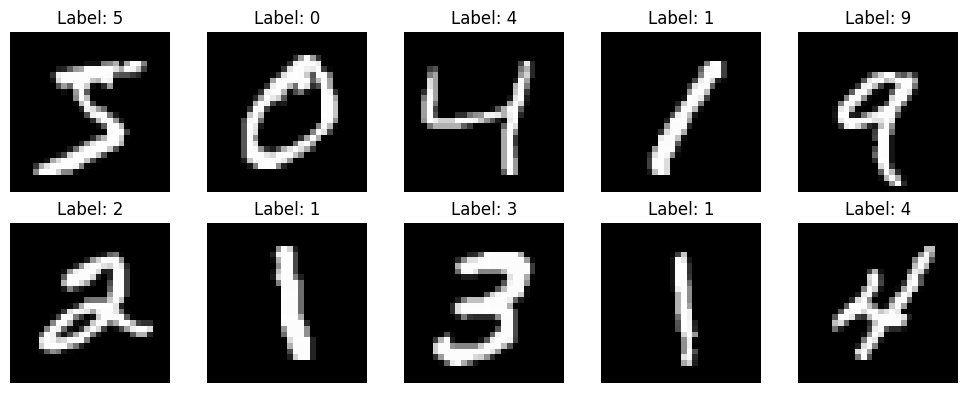

In [3]:
# Visualize a few samples — always look at your data before training
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## Step 2 — Preprocess

Two things to do before training:

1. **Normalize** pixels from `[0, 255]` → `[0.0, 1.0]`  
   (You know why — we covered this in Lesson 01)

2. **Flatten** images from `(28, 28)` → `(784,)`  
   Our first network uses Dense layers, which expect a 1D vector, not a 2D image.  
   (CNNs in Lesson 03 won't need this — they work directly on 2D.)

In [4]:
# Normalize
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# Flatten: (60000, 28, 28) → (60000, 784)
x_train = x_train.reshape(-1, 784)
x_test  = x_test.reshape(-1, 784)

print("x_train shape after preprocessing:", x_train.shape)
print("Pixel range:", x_train.min(), "to", x_train.max())

x_train shape after preprocessing: (60000, 784)
Pixel range: 0.0 to 1.0


---
## Step 3 — Build the Model

We'll build a 3-layer network:

```
Input (784,)
    ↓
Dense(128) + ReLU       → y = ReLU(Wx + b),  W shape: (784, 128)
    ↓
Dense(64) + ReLU        → y = ReLU(Wx + b),  W shape: (128, 64)
    ↓
Dense(10) + Softmax     → y = Softmax(Wx + b), W shape: (64, 10)
    ↓
Output: 10 probabilities (one per digit class)
```

**Why Softmax at the end?**  
We need the output to be a probability distribution — 10 numbers that sum to 1.0.  
Softmax does exactly that: it exponentiates each value and divides by the sum.

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

So if the network is confident the digit is 3, output[3] will be close to 1.0 and the rest close to 0.0.

In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(64,  activation='relu'),
    tf.keras.layers.Dense(10,  activation='softmax')
])

model.summary()

/mnt/c/Users/zenpu/OneDrive/Desktop/Python/face-detection-tf/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

**Read the summary carefully.**

Look at the `Param #` column. The first layer has **100,480 parameters**.  
Where does that number come from?

- Weights: `784 × 128 = 100,352`  
- Biases: `128`  
- Total: `100,352 + 128 = 100,480` ✓

Every single one of those numbers is a `tf.Variable` — learned by gradient descent.

---
## Step 4 — Compile

Before training, we tell Keras three things:

| Thing | What it is | Our choice |
|-------|-----------|------------|
| **Optimizer** | How to apply gradients | `adam` |
| **Loss** | What to minimize | `sparse_categorical_crossentropy` |
| **Metrics** | What to report | `accuracy` |

**Why `sparse_categorical_crossentropy`?**  
Our labels are integers like `3`, `7`, `1` — not one-hot vectors like `[0,0,0,1,0,0,0,0,0,0]`.  
The `sparse_` prefix means "accept integer labels directly".

**Why Adam and not plain SGD?**  
Adam is SGD with two improvements — it adapts the learning rate per parameter, and uses momentum.  
For now, just use it. We'll understand it deeply when we implement our own training loop.

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

---
## Step 5 — Train

`.fit()` runs the loop you described:
```
for each epoch:
    shuffle data
    for each batch:
        forward pass → loss → backward pass → update weights
```

`batch_size=32` means 32 images per gradient update.  
`epochs=5` means we go through the full 60,000 images 5 times.  
`validation_split=0.1` holds back 10% of training data to monitor overfitting.

In [7]:
history = model.fit(
    x_train, y_train,
    batch_size=32,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9228 - loss: 0.2635 - val_accuracy: 0.9665 - val_loss: 0.1096
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9680 - loss: 0.1074 - val_accuracy: 0.9728 - val_loss: 0.0935
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9762 - loss: 0.0754 - val_accuracy: 0.9757 - val_loss: 0.0842
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9825 - loss: 0.0563 - val_accuracy: 0.9780 - val_loss: 0.0774
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9856 - loss: 0.0450 - val_accuracy: 0.9810 - val_loss: 0.0727


---
## Step 6 — Evaluate and Visualize

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss:     {test_loss:.4f}")

Test accuracy: 0.9781
Test loss:     0.0747


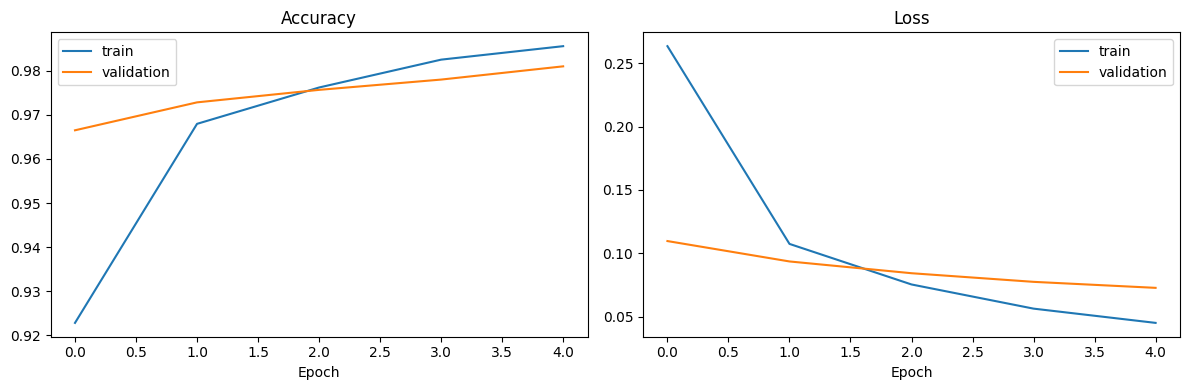

In [9]:
# Plot training vs validation accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


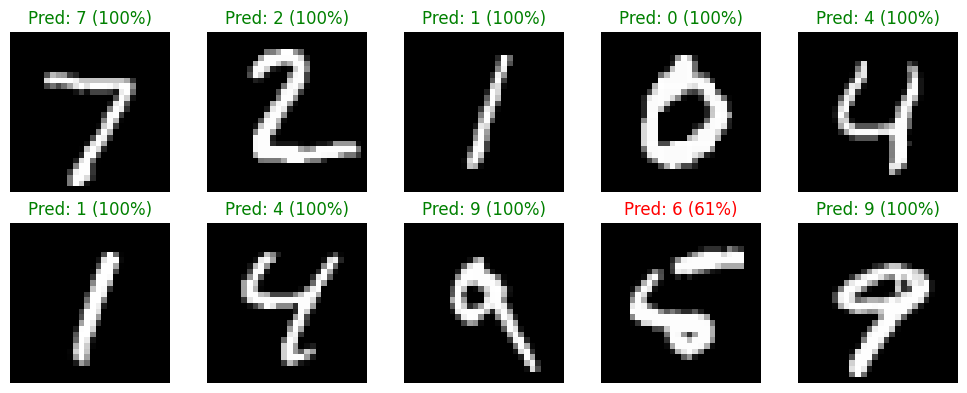

In [10]:
# Look at some predictions
predictions = model.predict(x_test[:10])

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_test[i].reshape(28, 28), cmap='gray')
    predicted = np.argmax(predictions[i])  # index of highest probability
    confidence = predictions[i][predicted]
    color = 'green' if predicted == y_test[i] else 'red'
    ax.set_title(f"Pred: {predicted} ({confidence:.0%})", color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## Step 7 — Look Inside a Prediction

Don't just trust the accuracy number. Understand what the network is actually outputting.

In [11]:
# Pick one image and inspect the raw output
sample = x_test[0:1]   # shape (1, 784) — batch of 1
output = model.predict(sample)[0]

print("Raw softmax output (probabilities):")
for digit, prob in enumerate(output):
    bar = '█' * int(prob * 40)
    print(f"  {digit}: {bar} {prob:.4f}")

print(f"\nPredicted digit: {np.argmax(output)}")
print(f"True label:      {y_test[0]}")
print(f"Sum of all probs: {output.sum():.6f}")  # should be ~1.0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Raw softmax output (probabilities):
  0:  0.0000
  1:  0.0000
  2:  0.0000
  3:  0.0001
  4:  0.0000
  5:  0.0000
  6:  0.0000
  7: ███████████████████████████████████████ 0.9999
  8:  0.0000
  9:  0.0001

Predicted digit: 7
True label:      7
Sum of all probs: 1.000000


---
## ✅ Lesson 02 — Summary

| Concept | What you learned |
|---------|------------------|
| `Sequential` | Stack layers in order |
| `Dense(n, activation)` | Fully connected layer: `f(Wx + b)` |
| `relu` | `max(0, x)` — kills negatives, keeps positives |
| `softmax` | Converts raw scores to probabilities summing to 1 |
| `compile` | Set optimizer, loss, metrics |
| `sparse_categorical_crossentropy` | Loss for integer labels, multi-class |
| `fit` | Runs your training loop automatically |
| `history` | Training curves — use to spot overfitting |
| `np.argmax` | Get the predicted class from softmax output |

---

## Think about these before Lesson 03:

1. We flattened the image from `(28, 28)` to `(784,)`. **What information did we lose by doing that?**
2. The network hit ~97% accuracy. **What do you think the 3% wrong cases look like?**
3. If train accuracy >> validation accuracy, what does that tell you about the model?

---

## 🚀 Next: Lesson 03 — Convolutional Neural Networks
We'll fix the flattening problem. CNNs look at the image *as a 2D structure* — that's why they dominate vision tasks, and why our face detector will use them.